<a href="https://colab.research.google.com/github/aabyyaann/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter6_Algorithm_Chains_and_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6 - Algorithm Chains and Pipelines

Notebook ini berisi ringkasan materi dan reproduksi kode dari **Chapter 6** buku *Introduction to Machine Learning with Python*.

Pada chapter ini, fokus pembahasan ada pada bagaimana membangun alur kerja machine learning yang lebih rapi, aman, dan mudah digunakan ulang. Di chapter sebelumnya, kita sudah belajar tentang evaluasi model dan grid search. Sekarang, kita masuk ke tahap yang lebih praktis, yaitu menyusun beberapa langkah machine learning ke dalam satu rangkaian proses menggunakan **pipeline**.

Topik utama pada chapter ini:
- alasan menggunakan pipeline
- preprocessing dan model dalam satu alur
- pipeline untuk mencegah data leakage
- grid search pada pipeline
- feature selection di dalam pipeline
- menggabungkan beberapa langkah transformasi

## Ringkasan Chapter

Dari chapter ini saya memahami bahwa proses machine learning biasanya tidak hanya terdiri dari satu model saja, tetapi juga melibatkan beberapa langkah lain seperti scaling, feature selection, transformasi data, dan tuning parameter. Jika semua langkah itu dilakukan secara manual, workflow bisa menjadi berantakan dan berisiko menyebabkan kesalahan, terutama **data leakage**.

Pipeline membantu menyatukan seluruh proses tersebut ke dalam satu objek. Dengan begitu, training, prediksi, evaluasi, dan tuning parameter bisa dilakukan dengan lebih konsisten. Selain lebih rapi, pipeline juga sangat membantu ketika menggunakan **cross-validation** atau **grid search**, karena setiap fold akan menjalankan preprocessing secara benar hanya pada data training fold tersebut.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.metrics import accuracy_score

# Import library untuk Chapter 6
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.metrics import accuracy_score

## 1. Mengapa Pipeline Dibutuhkan?

Dalam praktik machine learning, model biasanya tidak langsung menerima data mentah. Sebelum model dilatih, data sering perlu diproses terlebih dahulu, misalnya:
- melakukan scaling
- memilih fitur tertentu
- mengubah format data
- mengisi missing values
- melakukan encoding

Kalau langkah-langkah ini ditulis terpisah, kode akan lebih panjang dan rawan kesalahan. Salah satu masalah yang paling sering muncul adalah **data leakage**, yaitu ketika informasi dari test set ikut memengaruhi proses training.

Karena itu, buku memperkenalkan **pipeline** sebagai cara untuk menyusun preprocessing dan model ke dalam satu alur kerja.

In [2]:
# Load dataset breast cancer
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=0
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (426, 30)
X_test shape : (143, 30)
y_train shape: (426,)
y_test shape : (143,)


## 3. Workflow Manual Tanpa Pipeline

Sebelum menggunakan pipeline, saya coba dulu pendekatan manual:
1. scaling data training
2. scaling data test dengan scaler yang sama
3. melatih model
4. mengevaluasi model

Cara ini sebenarnya bisa dilakukan, tetapi semakin banyak langkah preprocessing, semakin sulit workflow ini dijaga agar tetap rapi.

In [3]:
# Pendekatan manual: scaling lalu training model
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC()
svm.fit(X_train_scaled, y_train)

manual_score = svm.score(X_test_scaled, y_test)
print("Test score without pipeline:", round(manual_score, 3))

Test score without pipeline: 0.944


### Interpretasi

Pada pendekatan manual, kita harus ingat bahwa scaler hanya boleh di-`fit` pada data training, lalu digunakan untuk mentransform data test. Kalau langkah ini salah dilakukan, misalnya scaler di-fit ke seluruh data, maka hasil evaluasi menjadi tidak valid.

Karena itu, pipeline lebih aman karena langkah-langkah tersebut dibungkus dalam satu proses yang konsisten.

## 4. Membuat Pipeline Sederhana

Sekarang saya gabungkan proses scaling dan model SVM ke dalam satu pipeline. Artinya, ketika pipeline di-fit, data akan otomatis melalui langkah scaling terlebih dahulu, lalu masuk ke model.

Urutan prosesnya menjadi:
1. MinMaxScaler
2. SVC

In [4]:
pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svm", SVC())
])

pipe.fit(X_train, y_train)
pipeline_score = pipe.score(X_test, y_test)

print("Test score with pipeline:", round(pipeline_score, 3))

Test score with pipeline: 0.944


### Interpretasi

Hasil akurasi dari pipeline seharusnya mirip dengan pendekatan manual, tetapi penulisannya jauh lebih rapi. Kita tidak perlu lagi menyimpan hasil `X_train_scaled` dan `X_test_scaled` secara terpisah. Semua langkah sudah diatur oleh pipeline.

Menurut saya, ini adalah keuntungan utama pipeline: **workflow menjadi lebih singkat, lebih aman, dan lebih mudah dipakai ulang**.

## 5. make_pipeline

Selain membuat pipeline dengan `Pipeline([...])`, scikit-learn juga menyediakan fungsi yang lebih singkat yaitu `make_pipeline()`.

Fungsinya sama, hanya saja nama step akan dibuat otomatis berdasarkan nama class transformer/model yang dipakai.

In [5]:
pipe2 = make_pipeline(MinMaxScaler(), SVC())

pipe2.fit(X_train, y_train)
score_pipe2 = pipe2.score(X_test, y_test)

print("Test score with make_pipeline:", round(score_pipe2, 3))
print("Pipeline steps:", pipe2.named_steps)

Test score with make_pipeline: 0.944
Pipeline steps: {'minmaxscaler': MinMaxScaler(), 'svc': SVC()}


### Catatan

Kalau menggunakan `make_pipeline`, nama step dibuat otomatis. Ini praktis untuk workflow sederhana. Namun, jika kita ingin mengatur nama step sendiri agar lebih jelas, maka `Pipeline([...])` biasanya lebih nyaman.

## 6. Pipeline dan Parameter Model

Salah satu kelebihan besar pipeline adalah parameter model di dalamnya tetap bisa diakses. Misalnya, jika kita ingin melihat atau mengubah parameter `C` pada SVM, kita bisa memanggil parameter tersebut melalui nama step di pipeline.

Format umumnya adalah:

`nama_step__nama_parameter`

Contoh:
- `svm__C`
- `svm__gamma`

In [6]:
# Melihat parameter yang ada di pipeline
pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'scaler', 'svm', 'scaler__clip', 'scaler__copy', 'scaler__feature_range', 'svm__C', 'svm__break_ties', 'svm__cache_size', 'svm__class_weight', 'svm__coef0', 'svm__decision_function_shape', 'svm__degree', 'svm__gamma', 'svm__kernel', 'svm__max_iter', 'svm__probability', 'svm__random_state', 'svm__shrinking', 'svm__tol', 'svm__verbose'])

## 7. Grid Search dengan Pipeline

Setelah pipeline dibuat, kita bisa langsung menggabungkannya dengan **GridSearchCV**. Ini sangat berguna karena preprocessing dan training model akan dilakukan dengan benar di setiap fold cross-validation.

Pada contoh ini, saya mencoba mencari nilai terbaik untuk parameter:
- `C`
- `gamma`

pada model SVM yang ada di dalam pipeline.

In [7]:
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best cross-validation score:", round(grid.best_score_, 3))
print("Best parameters:", grid.best_params_)
print("Test score:", round(grid.score(X_test, y_test), 3))

Best cross-validation score: 0.986
Best parameters: {'svm__C': 10, 'svm__gamma': 0.1}
Test score: 0.951


### Interpretasi

Di sini terlihat bahwa pipeline sangat memudahkan proses tuning. Saya tidak perlu lagi melakukan scaling secara manual di luar grid search. Semua proses sudah dibungkus di dalam satu objek.

Keuntungan pentingnya adalah **setiap fold cross-validation hanya belajar preprocessing dari training fold**, sehingga evaluasi menjadi lebih jujur dan tidak bocor ke validation fold.

## 8. Melihat Hasil Grid Search dalam Bentuk Tabel

Agar lebih mudah dianalisis, hasil dari grid search bisa diubah menjadi DataFrame. Dengan cara ini, saya bisa melihat kombinasi parameter mana yang menghasilkan skor terbaik, dan bagaimana perbandingan skor antar kombinasi.

In [8]:
results = pd.DataFrame(grid.cv_results_)
results[["param_svm__C", "param_svm__gamma", "mean_test_score", "rank_test_score"]].sort_values("rank_test_score").head(10)

,param_svm__C,param_svm__gamma,mean_test_score,rank_test_score
10,10.0,0.100,0.985964,1
7,1.0,1.000,0.981259,2
11,10.0,1.000,0.981231,3
13,100.0,0.010,0.978960,4
14,100.0,0.100,0.978878,5
15,100.0,1.000,0.971874,6
3,0.1,1.000,0.960164,7
6,1.0,0.100,0.957866,8
12,100.0,0.001,0.957866,8
9,10.0,0.010,0.955513,10


## 9. Visualisasi Skor Grid Search

Saya juga bisa memvisualisasikan hasil grid search agar hubungan antara parameter `C` dan `gamma` lebih mudah dipahami. Heatmap sederhana di bawah ini membantu melihat kombinasi parameter mana yang memberikan skor validasi paling tinggi.

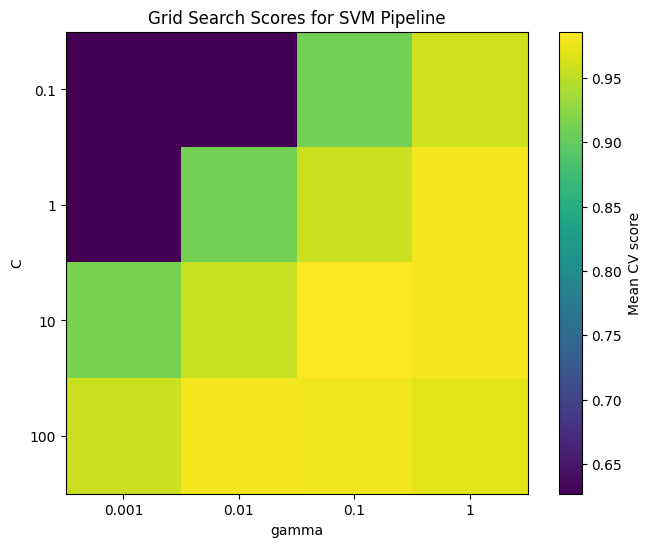

In [9]:
scores = np.array(results["mean_test_score"]).reshape(4, 4)

plt.figure(figsize=(8, 6))
plt.imshow(scores, interpolation="nearest", cmap="viridis")
plt.xlabel("gamma")
plt.ylabel("C")
plt.colorbar(label="Mean CV score")
plt.xticks(np.arange(len(param_grid["svm__gamma"])), param_grid["svm__gamma"])
plt.yticks(np.arange(len(param_grid["svm__C"])), param_grid["svm__C"])
plt.title("Grid Search Scores for SVM Pipeline")
plt.show()

### Interpretasi

Dari heatmap di atas, saya bisa melihat bahwa beberapa kombinasi parameter memberikan hasil yang jauh lebih baik daripada kombinasi lainnya. Ini menunjukkan bahwa tuning parameter memang penting, karena performa model tidak hanya bergantung pada algoritmanya saja, tetapi juga pada konfigurasi parameter yang digunakan.

## 10. Menambahkan Feature Selection ke dalam Pipeline

Selain scaling, langkah preprocessing lain yang cukup penting adalah **feature selection**. Kadang tidak semua fitur benar-benar membantu model. Beberapa fitur bisa saja kurang relevan atau justru menambah noise.

Pada contoh ini, saya menambahkan `SelectPercentile` ke dalam pipeline untuk memilih sebagian fitur terbaik sebelum data masuk ke model.

In [10]:
pipe_select = Pipeline([
    ("select", SelectPercentile(score_func=f_classif)),
    ("svm", SVC())
])

### Interpretasi

Pada pipeline ini, urutannya menjadi:
1. data di-scale
2. fitur terbaik dipilih
3. model SVM dilatih

Dengan pipeline, semua langkah tersebut tetap terasa seperti satu model utuh. Ini sangat membantu saat workflow mulai kompleks.

## 11. Grid Search pada Pipeline yang Lebih Kompleks

Karena feature selection juga punya parameter, kita bisa sekaligus mencari:
- berapa persen fitur terbaik yang dipilih
- berapa nilai `C` terbaik untuk SVM

Dengan kata lain, grid search tidak hanya mencari parameter model, tetapi juga parameter preprocessing.

In [11]:
param_grid_select = {
    "select__percentile": [10, 30, 50, 70, 100],
    "svm__C": [0.1, 1, 10, 100]
}

grid_select = GridSearchCV(pipe_select, param_grid_select, cv=5)
grid_select.fit(X_train, y_train)

print("Best parameters:", grid_select.best_params_)
print("Best CV score :", round(grid_select.best_score_, 3))
print("Test score    :", round(grid_select.score(X_test, y_test), 3))

Best parameters: {'select__percentile': 30, 'svm__C': 100}
Best CV score : 0.939
Test score    : 0.909


### Interpretasi

Bagian ini menunjukkan salah satu kekuatan pipeline: kita bisa men-tuning **seluruh alur kerja**, bukan hanya model di akhir. Ini lebih realistis dengan kondisi machine learning di dunia nyata, karena performa model sangat dipengaruhi juga oleh preprocessing yang dilakukan.

## 12. Melihat Fitur yang Dipilih

Karena pipeline menggunakan `SelectPercentile`, saya juga bisa melihat fitur mana saja yang dipilih oleh proses feature selection. Hal ini berguna untuk memahami apakah fitur-fitur tertentu memang dianggap penting oleh metode seleksi fitur.

In [12]:
# Ambil masker fitur terpilih dari pipeline terbaik
best_pipe = grid_select.best_estimator_
selected_mask = best_pipe.named_steps["select"].get_support()

selected_features = cancer.feature_names[selected_mask]
print("Selected features:")
for feat in selected_features:
    print("-", feat)

Selected features:
- mean radius
- mean perimeter
- mean area
- mean concavity
- mean concave points
- worst radius
- worst perimeter
- worst area
- worst concave points


## 13. Membandingkan Model dengan dan tanpa Feature Selection

Agar lebih jelas, saya bandingkan performa beberapa pendekatan:
1. model SVM tanpa pipeline
2. pipeline sederhana (scaling + SVM)
3. pipeline dengan feature selection

Perbandingan ini membantu melihat apakah feature selection benar-benar memberi dampak pada performa model.

In [13]:
score_select = grid_select.score(X_test, y_test)
print("Pipeline scaling + feature selection + SVM test score:", round(score_select, 3))

Pipeline scaling + feature selection + SVM test score: 0.909


In [14]:
comparison = pd.DataFrame({
    "Model": [
        "Manual scaling + SVM",
        "Pipeline scaling + SVM",
        "Pipeline scaling + feature selection + SVM"
    ],
    "Test Score": [
        manual_score,
        pipeline_score,
        score_select
    ]
})

comparison

,Model,Test Score
0,Manual scaling + SVM,0.944056
1,Pipeline scaling + SVM,0.944056
2,Pipeline scaling + feature selection + SVM,0.909091


## 14. Visualisasi Perbandingan Skor

Supaya lebih mudah dibaca, saya tampilkan juga perbandingan skor ketiga pendekatan tersebut dalam bentuk grafik batang.

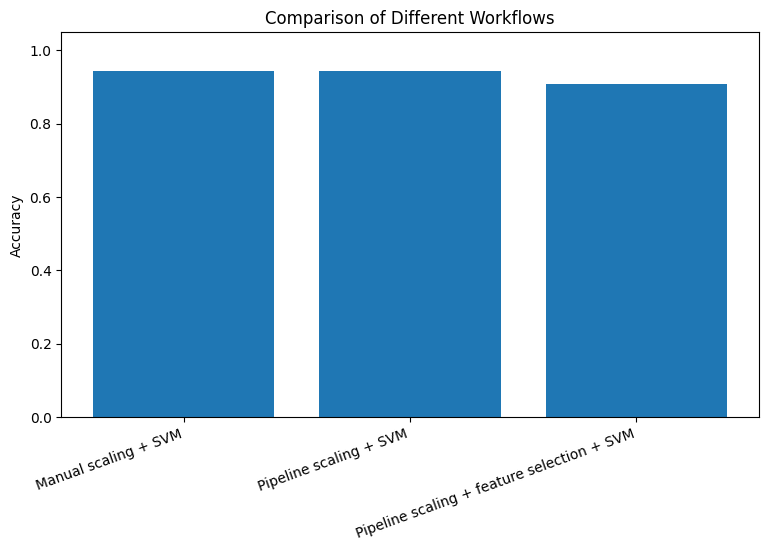

In [15]:
plt.figure(figsize=(9, 5))
plt.bar(comparison["Model"], comparison["Test Score"])
plt.ylabel("Accuracy")
plt.title("Comparison of Different Workflows")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.show()

### Interpretasi

Dari grafik ini, saya bisa melihat apakah penggunaan pipeline dan feature selection memberikan peningkatan performa atau tidak. Walaupun tidak selalu menaikkan skor secara drastis, pipeline tetap sangat bermanfaat karena membuat proses machine learning lebih konsisten dan lebih aman.

## 15. Pipeline pada Dataset Iris

Agar tidak hanya menggunakan satu dataset, saya juga mencoba pipeline sederhana pada **dataset Iris**. Tujuannya bukan untuk mendapatkan hasil terbaik, tetapi untuk melihat bahwa pipeline bisa diterapkan ke berbagai dataset klasifikasi dengan pola yang sama.

In [16]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, random_state=42
)

iris_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

iris_pipe.fit(X_train_i, y_train_i)
iris_score = iris_pipe.score(X_test_i, y_test_i)

print("Iris pipeline test score:", round(iris_score, 3))

Iris pipeline test score: 1.0


## 16. Grid Search pada Pipeline KNN

Pada contoh Iris, saya juga bisa melakukan tuning parameter jumlah tetangga (`n_neighbors`) untuk KNN. Karena modelnya berada di dalam pipeline, parameter tersebut ditulis dengan format:

`knn__n_neighbors`

In [17]:
param_grid_iris = {
    "knn__n_neighbors": range(1, 11)
}

grid_iris = GridSearchCV(iris_pipe, param_grid_iris, cv=5)
grid_iris.fit(X_train_i, y_train_i)

print("Best parameter:", grid_iris.best_params_)
print("Best CV score :", round(grid_iris.best_score_, 3))
print("Test score    :", round(grid_iris.score(X_test_i, y_test_i), 3))

Best parameter: {'knn__n_neighbors': 8}
Best CV score : 0.938
Test score    : 1.0


## 17. Visualisasi Pengaruh Nilai n_neighbors

Untuk melihat perubahan performa KNN terhadap jumlah tetangga, saya tampilkan hasil grid search ke dalam grafik sederhana.

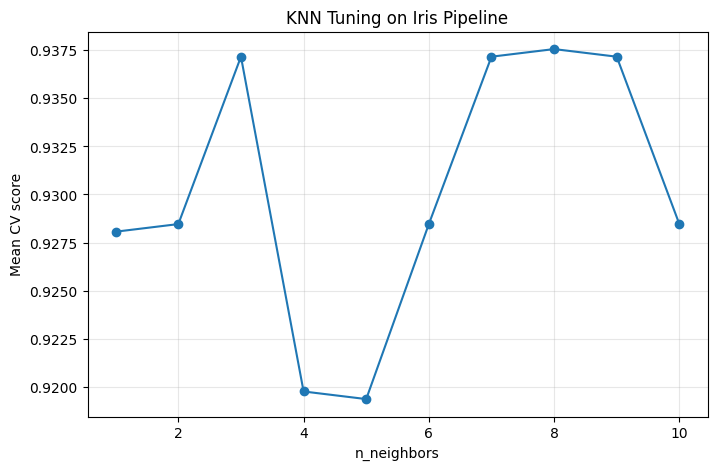

In [18]:
iris_results = pd.DataFrame(grid_iris.cv_results_)

plt.figure(figsize=(8, 5))
plt.plot(
    iris_results["param_knn__n_neighbors"].astype(int),
    iris_results["mean_test_score"],
    marker="o"
)
plt.xlabel("n_neighbors")
plt.ylabel("Mean CV score")
plt.title("KNN Tuning on Iris Pipeline")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretasi

Grafik ini membantu melihat nilai `n_neighbors` mana yang paling cocok untuk dataset Iris. Dengan pipeline, tuning seperti ini bisa dilakukan tanpa perlu memisahkan preprocessing dan model secara manual.

## 18. Hal Penting yang Saya Pahami dari Chapter Ini

Setelah mencoba beberapa contoh di atas, ada beberapa hal penting yang saya pahami:

- pipeline bukan sekadar alat untuk merapikan kode, tetapi juga membantu menjaga proses evaluasi tetap benar
- preprocessing sebaiknya tidak dilakukan terpisah dari model ketika menggunakan cross-validation
- grid search menjadi jauh lebih nyaman jika model dibungkus dalam pipeline
- parameter preprocessing dan parameter model bisa dituning bersama
- workflow machine learning yang rapi akan memudahkan eksperimen, debugging, dan reproduksi hasil

## Kesimpulan Chapter 6

Pada chapter ini saya belajar bahwa pipeline adalah salah satu komponen penting dalam workflow machine learning. Pipeline membantu menggabungkan preprocessing dan model ke dalam satu alur yang konsisten, sehingga kode menjadi lebih rapi dan risiko data leakage bisa dikurangi.

Selain itu, pipeline juga sangat berguna saat melakukan **grid search** dan **cross-validation**, karena semua langkah preprocessing akan dijalankan dengan benar di setiap fold. Dengan kata lain, chapter ini bukan hanya membahas cara membuat model, tetapi juga cara membangun **workflow machine learning yang lebih baik, lebih aman, dan lebih mudah digunakan ulang**.

## Penutup

Secara pribadi, menurut saya chapter ini sangat penting karena mulai memperlihatkan bentuk workflow machine learning yang lebih realistis. Kalau chapter sebelumnya lebih fokus pada model dan evaluasi, chapter ini mulai menekankan bagaimana menyusun seluruh proses dari awal sampai akhir dengan rapi.

Pipeline terlihat sederhana, tetapi dampaknya besar sekali, terutama ketika proyek machine learning sudah mulai memiliki banyak langkah preprocessing dan tuning parameter.